In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
df = pd.read_csv("Wine dataset.csv", usecols=[0,1,2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']

In [7]:
df

,Class label,Alcohol,Malic acid
0,class,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95
...,...,...,...
174,3,13.71,5.65
175,3,13.4,3.91
176,3,13.27,4.28
177,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

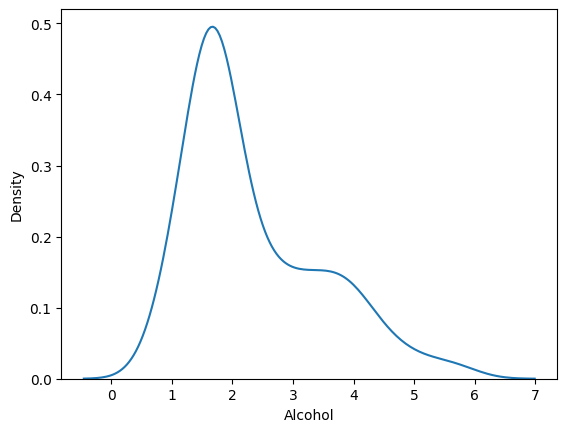

In [14]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

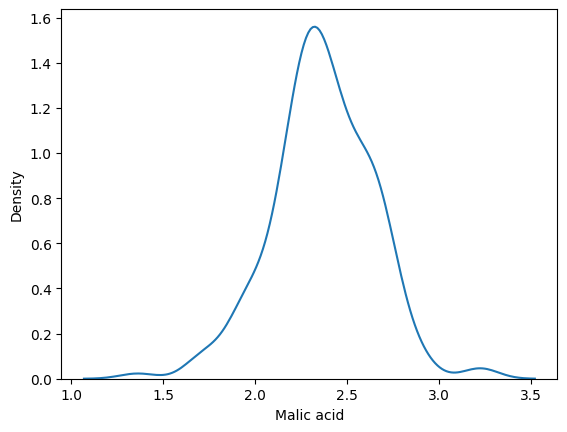

In [16]:
sns.kdeplot(df['Malic acid'])

In [27]:
df= df.apply(pd.to_numeric)

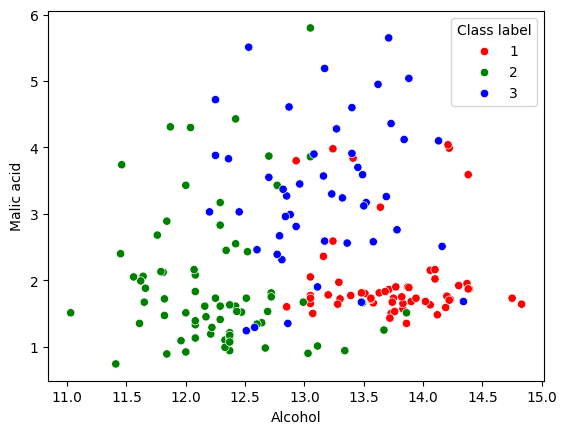

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

color_dict = {
    1: 'red',
    2: 'green',
    3: 'blue'
}

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Malic acid',
    hue='Class label',
    palette=color_dict
)

plt.show()

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Class label',axis=1),
                                                df['Class label'],
                                                test_size=0.3,
                                                random_state=0)
X_train.shape,X_test.shape

((124, 2), (54, 2))

In [39]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


#fit the scaler to the train set, it will learn the prarmeters
scaler.fit(X_train)

#transform train and test sets 

X_train_scaled =scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [41]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [42]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


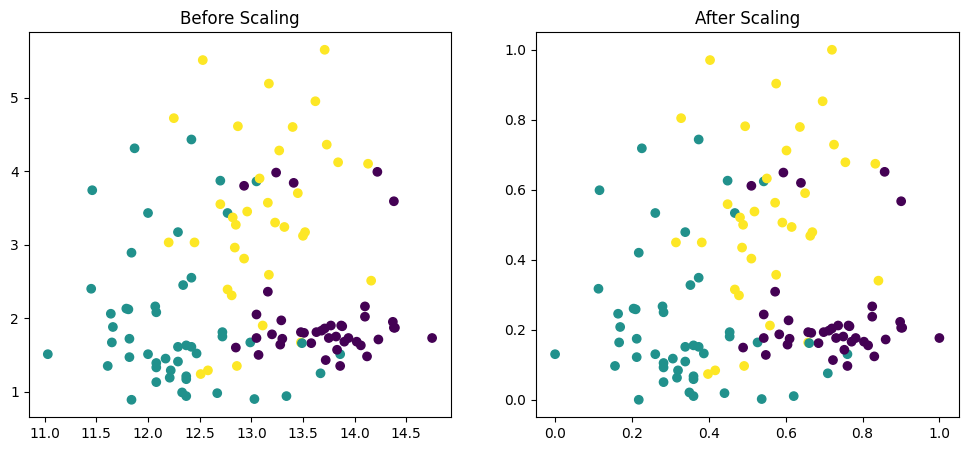

In [43]:
fig,(ax1,ax2)= plt.subplots(ncols=2, figsize=(12, 5,))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

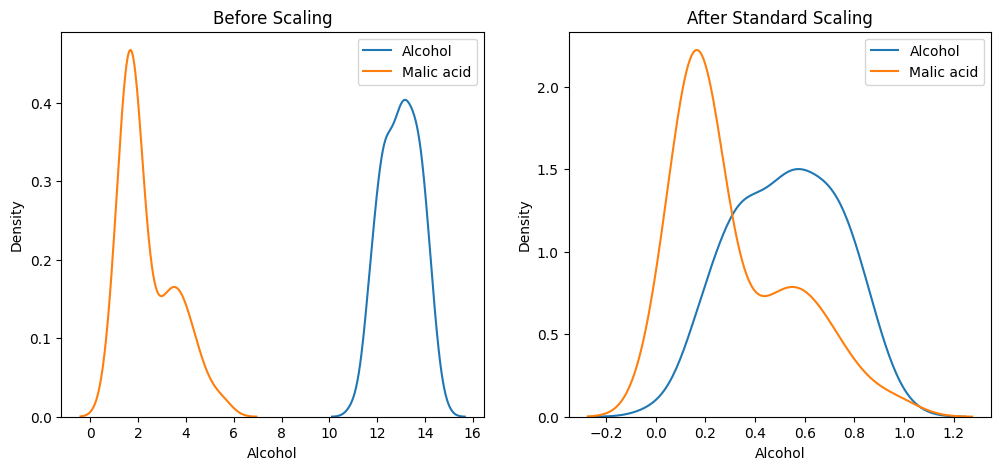

In [44]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['Malic acid'], ax=ax1, label='Malic acid')
ax1.legend()

ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2, label='Malic acid')
ax2.legend()

plt.show()

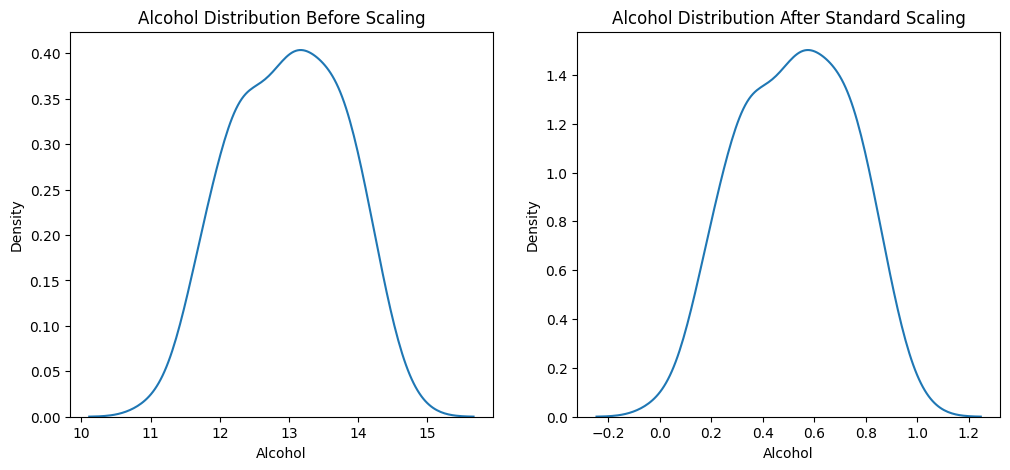

In [46]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)

plt.show()